# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure that simulates replication through S-phase. And can normalize read counts in the genome by the expected copy number through time.

## Procedure:
1. Define Genome: $G = 1...n$ (10kb per element)
2. Define Origins: $O = o_1 = 1, o_2 = 3, ... o_m $
3. Define origin speed: 10kb/min
4. Create replication matrix of expected copy number at each position per time:
$R = (t \times n )$
5. Simluate replication, fill out $R$ based on simulation of origins.
6. Create a reads per genome matrix across time: $C = (t \times n)$
    - Assume equal reads at all times to start
7. Normalize the read counts per each time point:
    1. Compute the total read depth per timepoint.
    2. Normalize read bins in which the DNA has been replicated (scaled down by half).
    3. Compute the updated read depth adjusted for the replicated DNA (read count should be lowered).
    4. Normalize the updated read counts to match the original total read depth.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


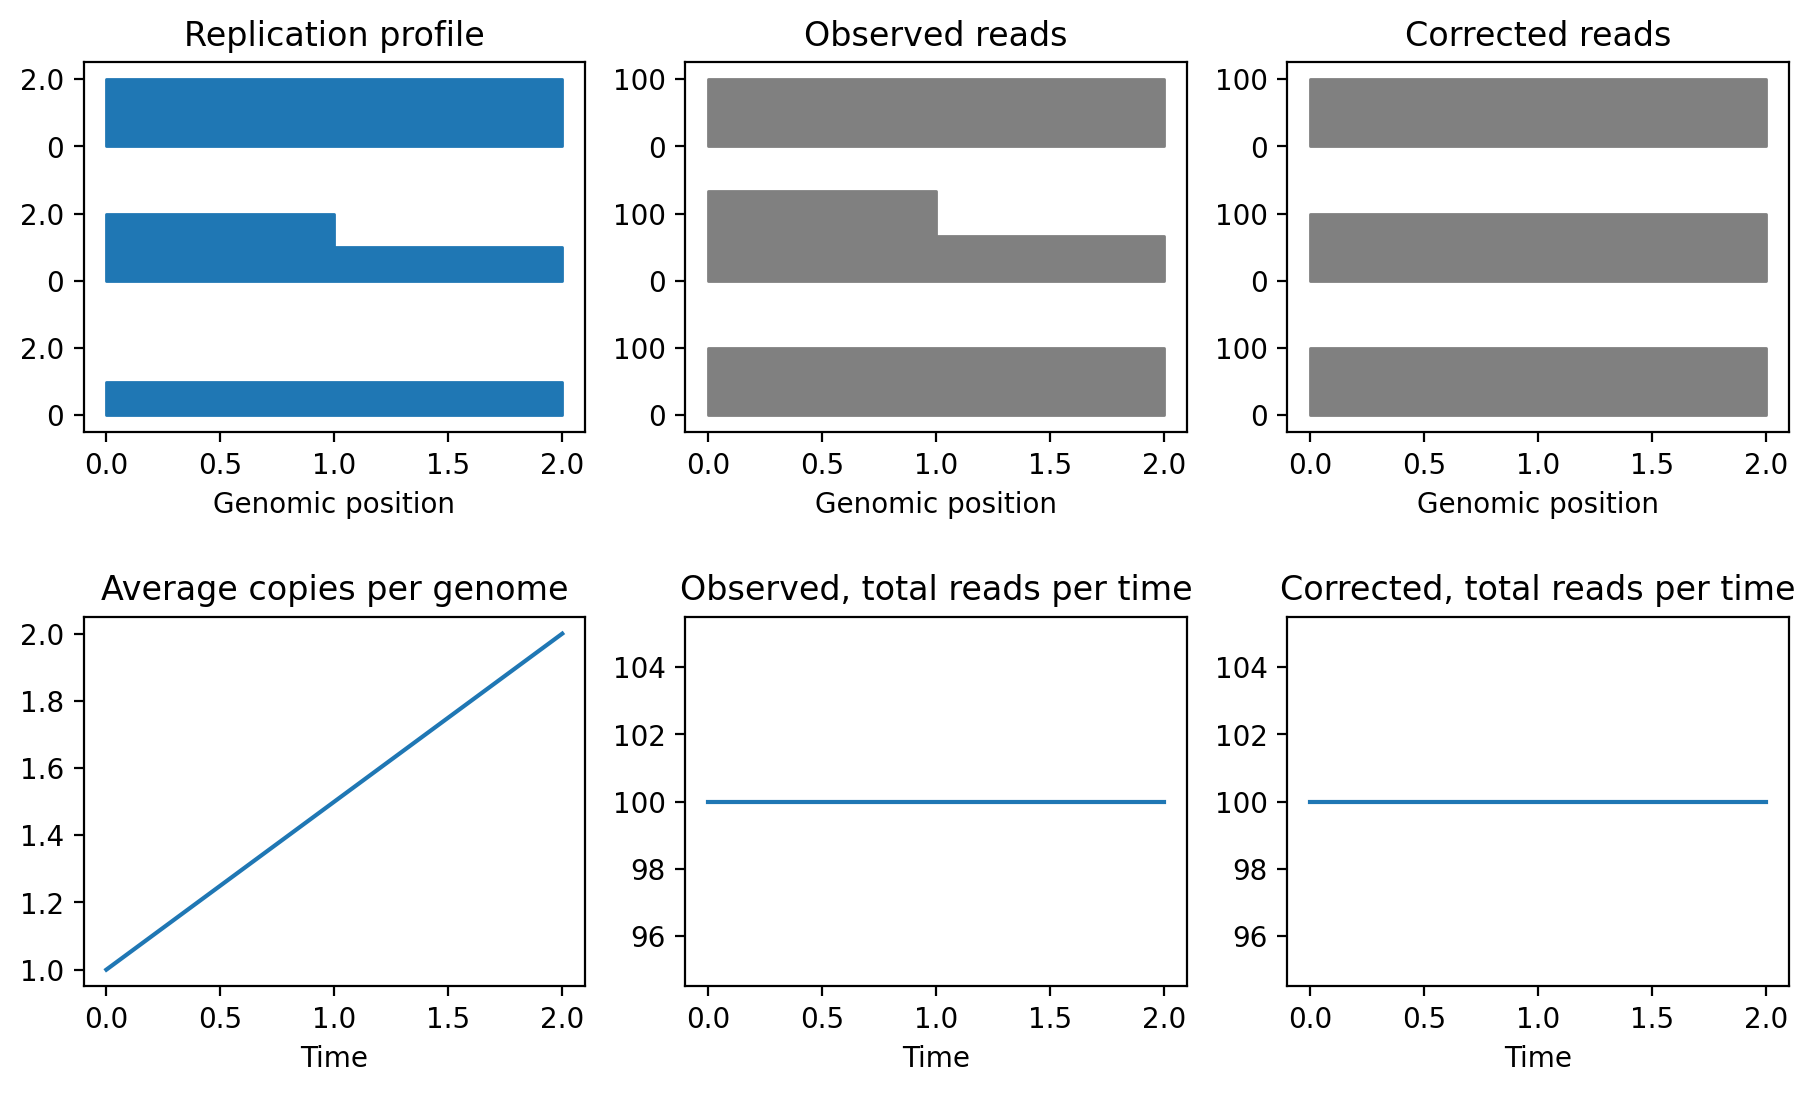

In [231]:
import numpy as np
from src.CopyNumberCorrection import correct_copy_number

# If we observe even reads across the time course
observed_reads = np.array([
    [100, 100],
    [200 *2/3, 100*2/3],
    [200 *1/2, 200*1/2]],
)

replication_profile_timecourse = np.array([
    [1, 1],
    [2, 1],
    [2, 2]],
)

from src.CopyNumberCorrection import CopyNumberCorrection

copy_corrector = CopyNumberCorrection(observed_reads, replication_profile_timecourse)
copy_corrector.plot_observed_vs_corrected()

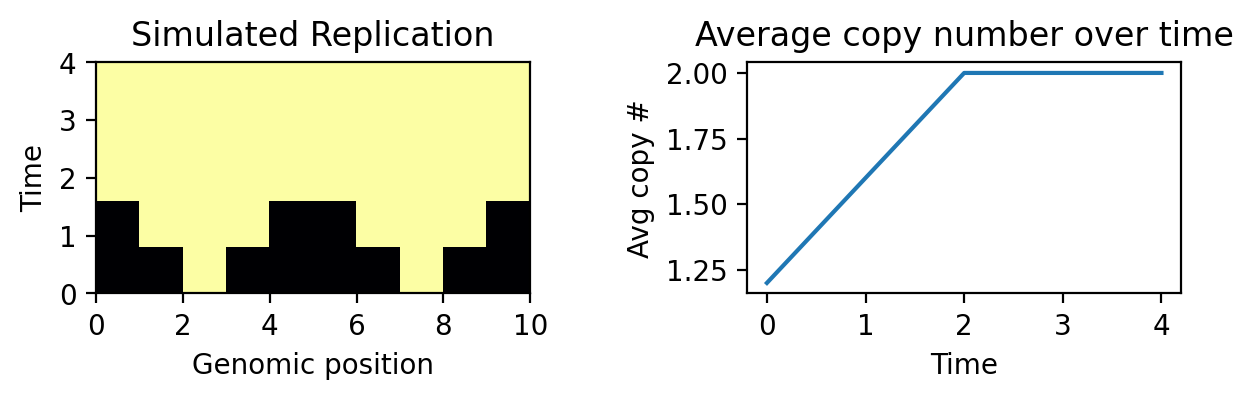

In [256]:
from src.ToyReplication import ToyReplication

n = 10 # 100, 10 kb windows
length_timecourse = 4
step_min = 1 # Progress time by 10 minutes

# Origin firing times and locations
origins = {
    0:[2, 7],
}

toy_repl_example = ToyReplication(n=n, step_min=step_min, origins=origins, 
    length_timecourse=length_timecourse)
toy_repl_example.replicate()
toy_repl_example.plot_replication()

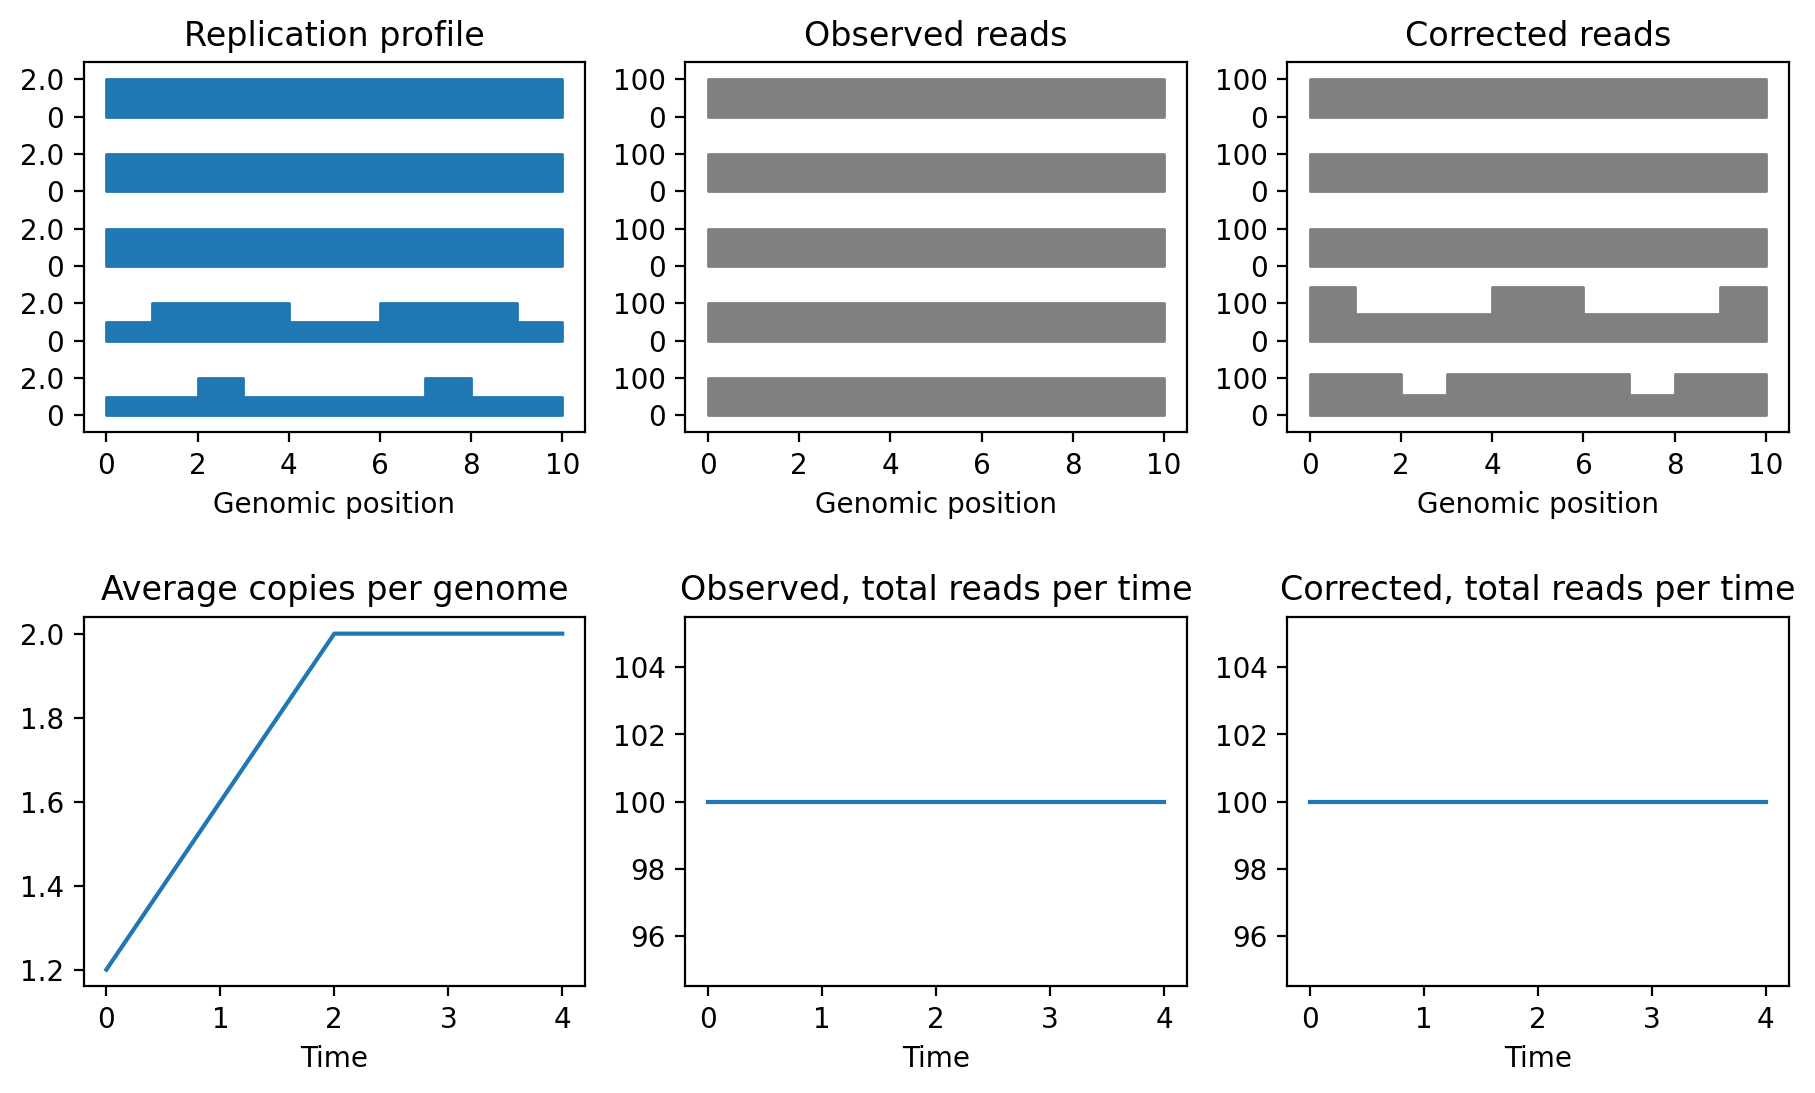

In [257]:
replication_profile_timecourse = toy_repl_example.replication_matrix
observed_reads = np.zeros_like(replication_profile_timecourse)+100.

copy_corrector = CopyNumberCorrection(observed_reads, replication_profile_timecourse)
copy_corrector.plot_observed_vs_corrected()
